1. Problem Definition

For this project we will investigate the Boston House Price dataset. Each record in the database
describes a Boston suburb or town. The data was drawn from the Boston Standard Metropolitan
Statistical Area (SMSA) in 1970. The attributes are defined as follows (taken from the UCI
Machine Learning Repository1):
1. CRIM: per capita crime rate by town
2. ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
3. INDUS: proportion of non-retail business acres per town
4. CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
5. NOX: nitric oxides concentration (parts per 10 million)
6. RM: số phòng trung bình trên mỗi căn hộ
7. AGE: tỷ lệ các đơn vị thuộc sở hữu của chủ nhà được xây dựng trước năm 1940
8. DIS: khoảng cách có trọng số đến năm trung tâm việc làm Boston
9. RAD: chỉ số về khả năng tiếp cận các đường cao tốc xuyên tâm1
10. TAX: thuế suất tài sản toàn giá trị trên $10,0002
11. PTRATIO: tỷ lệ học sinh-giáo viên theo thị trấn
12. B: $1000(Bk - 0.63)^2$ trong đó 5$Bk$ là tỷ lệ người da đen theo thị trấn
13. LSTAT: % tình trạng 7thấp hơn của dân số
14. MEDV: Giá trị trung bình của những ngôi nhà thuộc sở hữu của chủ nhà tính bằng $\$1000$



### 2. Load the Dataset


In [3]:
# Load libraries
import numpy
import pandas as pd
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error

In [4]:
# Load dataset
filename = 'housing.csv'
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO',
'B', 'LSTAT', 'MEDV']
dataset = read_csv(filename, delim_whitespace=True, names=names)

C:\Users\USER\AppData\Local\Temp\ipykernel_2512\297170968.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataset = read_csv(filename, delim_whitespace=True, names=names)


3. Analyze Data
- Descriptive Statistics

In [5]:
# shape
print(dataset.shape)

(506, 14)


bộ dữ liệu có 506 dòng và 14 cột

In [6]:
# types
print(dataset.dtypes)

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object


In [7]:
# head
print(dataset.head(20))

       CRIM    ZN  INDUS  CHAS    NOX     RM    AGE     DIS  RAD    TAX  \
0   0.00632  18.0   2.31     0  0.538  6.575   65.2  4.0900    1  296.0   
1   0.02731   0.0   7.07     0  0.469  6.421   78.9  4.9671    2  242.0   
2   0.02729   0.0   7.07     0  0.469  7.185   61.1  4.9671    2  242.0   
3   0.03237   0.0   2.18     0  0.458  6.998   45.8  6.0622    3  222.0   
4   0.06905   0.0   2.18     0  0.458  7.147   54.2  6.0622    3  222.0   
5   0.02985   0.0   2.18     0  0.458  6.430   58.7  6.0622    3  222.0   
6   0.08829  12.5   7.87     0  0.524  6.012   66.6  5.5605    5  311.0   
7   0.14455  12.5   7.87     0  0.524  6.172   96.1  5.9505    5  311.0   
8   0.21124  12.5   7.87     0  0.524  5.631  100.0  6.0821    5  311.0   
9   0.17004  12.5   7.87     0  0.524  6.004   85.9  6.5921    5  311.0   
10  0.22489  12.5   7.87     0  0.524  6.377   94.3  6.3467    5  311.0   
11  0.11747  12.5   7.87     0  0.524  6.009   82.9  6.2267    5  311.0   
12  0.09378  12.5   7.87 

In [9]:
# descriptions
set_option('display.width', 100)
set_option('display.max_columns', 10)
set_option('display.precision', 3)
print(dataset.describe())

          CRIM       ZN    INDUS     CHAS      NOX  ...      TAX  PTRATIO        B    LSTAT  \
count  506.000  506.000  506.000  506.000  506.000  ...  506.000  506.000  506.000  506.000   
mean     3.614   11.364   11.137    0.069    0.555  ...  408.237   18.456  356.674   12.653   
std      8.602   23.322    6.860    0.254    0.116  ...  168.537    2.165   91.295    7.141   
min      0.006    0.000    0.460    0.000    0.385  ...  187.000   12.600    0.320    1.730   
25%      0.082    0.000    5.190    0.000    0.449  ...  279.000   17.400  375.377    6.950   
50%      0.257    0.000    9.690    0.000    0.538  ...  330.000   19.050  391.440   11.360   
75%      3.677   12.500   18.100    0.000    0.624  ...  666.000   20.200  396.225   16.955   
max     88.976  100.000   27.740    1.000    0.871  ...  711.000   22.000  396.900   37.970   

          MEDV  
count  506.000  
mean    22.533  
std      9.197  
min      5.000  
25%     17.025  
50%     21.200  
75%     25.000  
max     

In [12]:
# correlation
set_option('display.width', 100)
set_option('display.max_columns', 10)
set_option('display.precision', 3)
print(dataset.corr(method='pearson'))

#Listing 20.11: Print the

          CRIM     ZN  INDUS   CHAS    NOX  ...    TAX  PTRATIO      B  LSTAT   MEDV
CRIM     1.000 -0.200  0.407 -0.056  0.421  ...  0.583    0.290 -0.385  0.456 -0.388
ZN      -0.200  1.000 -0.534 -0.043 -0.517  ... -0.315   -0.392  0.176 -0.413  0.360
INDUS    0.407 -0.534  1.000  0.063  0.764  ...  0.721    0.383 -0.357  0.604 -0.484
CHAS    -0.056 -0.043  0.063  1.000  0.091  ... -0.036   -0.122  0.049 -0.054  0.175
NOX      0.421 -0.517  0.764  0.091  1.000  ...  0.668    0.189 -0.380  0.591 -0.427
RM      -0.219  0.312 -0.392  0.091 -0.302  ... -0.292   -0.356  0.128 -0.614  0.695
AGE      0.353 -0.570  0.645  0.087  0.731  ...  0.506    0.262 -0.274  0.602 -0.377
DIS     -0.380  0.664 -0.708 -0.099 -0.769  ... -0.534   -0.232  0.292 -0.497  0.250
RAD      0.626 -0.312  0.595 -0.007  0.611  ...  0.910    0.465 -0.444  0.489 -0.382
TAX      0.583 -0.315  0.721 -0.036  0.668  ...  1.000    0.461 -0.442  0.544 -0.469
PTRATIO  0.290 -0.392  0.383 -0.122  0.189  ...  0.461    1.000 -

4 Data Visualizations

- Unimodal Data Visualizations

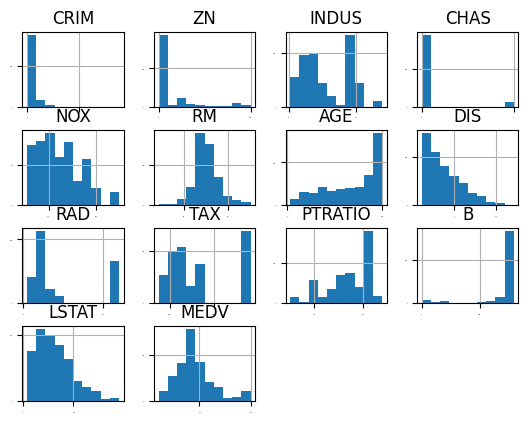

In [13]:
# histograms
dataset.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1)
pyplot.show()

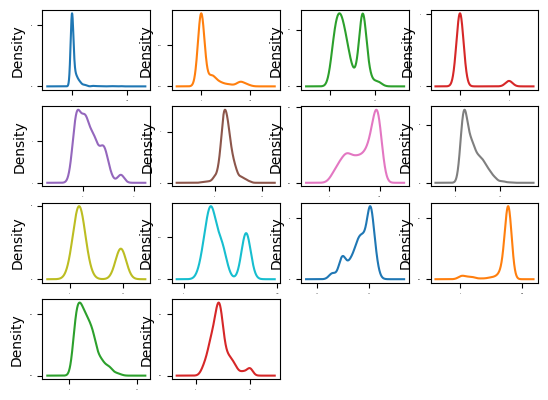

In [14]:
# density
dataset.plot(kind='density', subplots=True, layout=(4,4), sharex=False, legend=False,
fontsize=1)
pyplot.show()

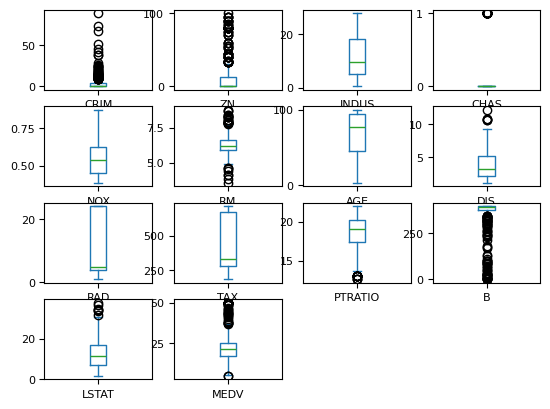

In [15]:
# box and whisker plots
dataset.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False,
fontsize=8)
pyplot.show()

- Multimodal Data Visualizations

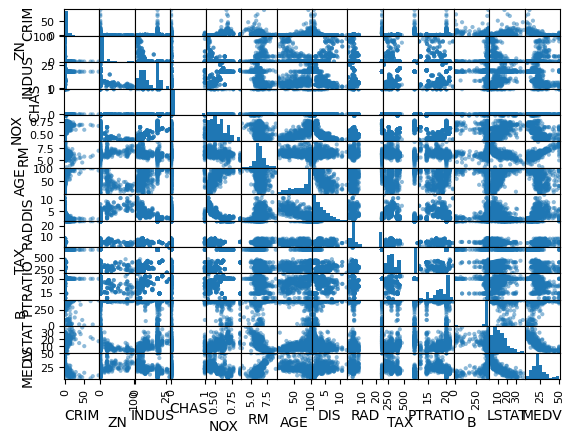

In [16]:
# scatter plot matrix
scatter_matrix(dataset)
pyplot.show()

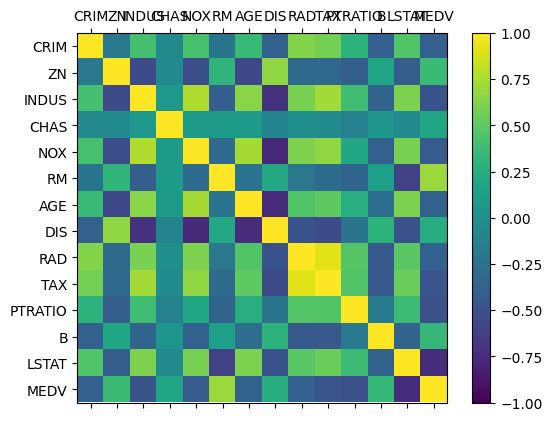

In [17]:
# correlation matrix
fig = pyplot.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(dataset.corr(), vmin=-1, vmax=1, interpolation='none')
fig.colorbar(cax)
ticks = numpy.arange(0,14,1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(names)
ax.set_yticklabels(names)
pyplot.show()

4. Validation Dataset

In [18]:
# Split-out validation dataset
array = dataset.values
X = array[:,0:13]
Y = array[:,13]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y,
test_size=validation_size, random_state=seed)

5. Evaluate Algorithms: Baseline

In [19]:
# Test options and evaluation metric
num_folds = 10
seed = 7
scoring = 'neg_mean_squared_error'

In [20]:
# Spot-Check Algorithms
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso()))
models.append(('EN', ElasticNet()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVR', SVR()))

In [30]:
# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)

    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: -21.685390 (7.402819)
LASSO: -27.102046 (10.125652)
EN: -27.933822 (10.379421)
KNN: -41.300083 (14.223923)
CART: -25.907374 (16.125588)
SVR: -67.764597 (27.679608)


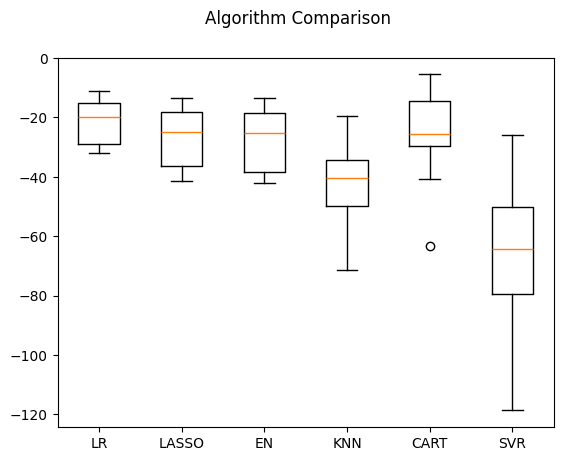

In [31]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

6. Evaluate Algorithms: Standardization

In [34]:
# Standardize the dataset
pipelines = []
pipelines.append(('ScaledLR', Pipeline([('Scaler', StandardScaler()),('LR',
    LinearRegression())])))
pipelines.append(('ScaledLASSO', Pipeline([('Scaler', StandardScaler()),('LASSO',
    Lasso())])))
pipelines.append(('ScaledEN', Pipeline([('Scaler', StandardScaler()),('EN',
    ElasticNet())])))
pipelines.append(('ScaledKNN', Pipeline([('Scaler', StandardScaler()),('KNN',
    KNeighborsRegressor())])))
pipelines.append(('ScaledCART', Pipeline([('Scaler', StandardScaler()),('CART',
    DecisionTreeRegressor())])))
pipelines.append(('ScaledSVR', Pipeline([('Scaler', StandardScaler()),('SVR', SVR())])))
results = []
names = []
for name, model in pipelines:
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)

    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

ScaledLR: -21.685390 (7.402819)
ScaledLASSO: -27.201752 (9.174094)
ScaledEN: -28.201577 (10.999139)
ScaledKNN: -20.222217 (8.606278)
ScaledCART: -26.537817 (17.323070)
ScaledSVR: -29.854897 (13.136418)


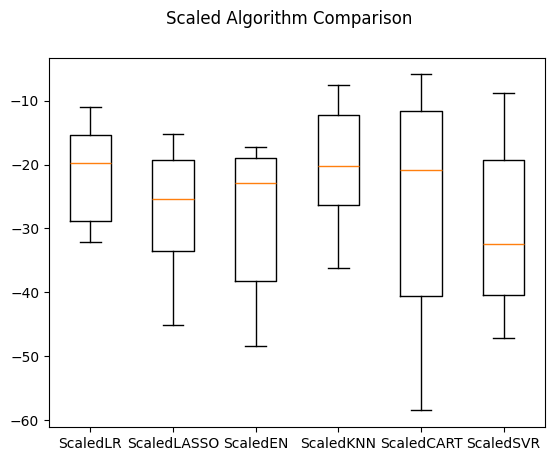

In [35]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

7. Improve Results With Tuning

In [37]:
# KNN Algorithm tuning
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
k_values = numpy.array([1,3,5,7,9,11,13,15,17,19,21])
param_grid = dict(n_neighbors=k_values)
model = KNeighborsRegressor()
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledX, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: -20.592475 using {'n_neighbors': np.int64(3)}
-23.021238 (13.089676) with: {'n_neighbors': np.int64(1)}
-20.592475 (9.563187) with: {'n_neighbors': np.int64(3)}
-20.676425 (8.961310) with: {'n_neighbors': np.int64(5)}
-21.332890 (8.669858) with: {'n_neighbors': np.int64(7)}
-20.611198 (8.747019) with: {'n_neighbors': np.int64(9)}
-21.330844 (9.352890) with: {'n_neighbors': np.int64(11)}
-21.286892 (9.674787) with: {'n_neighbors': np.int64(13)}
-21.835121 (9.608593) with: {'n_neighbors': np.int64(15)}
-22.611591 (9.865640) with: {'n_neighbors': np.int64(17)}
-23.434037 (10.761271) with: {'n_neighbors': np.int64(19)}
-24.179264 (11.245744) with: {'n_neighbors': np.int64(21)}


8. Ensemble Methods

In [39]:
# ensembles
ensembles = []
ensembles.append(('ScaledAB', Pipeline([('Scaler', StandardScaler()),('AB',
    AdaBoostRegressor())])))
ensembles.append(('ScaledGBM', Pipeline([('Scaler', StandardScaler()),('GBM',
    GradientBoostingRegressor())])))
ensembles.append(('ScaledRF', Pipeline([('Scaler', StandardScaler()),('RF',
    RandomForestRegressor())])))
ensembles.append(('ScaledET', Pipeline([('Scaler', StandardScaler()),('ET',
    ExtraTreesRegressor())])))
results = []
names = []
for name, model in ensembles:
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)


ScaledAB: -15.717567 (5.994852)
ScaledGBM: -9.680049 (4.598517)
ScaledRF: -12.456011 (6.094170)
ScaledET: -9.462876 (4.404061)


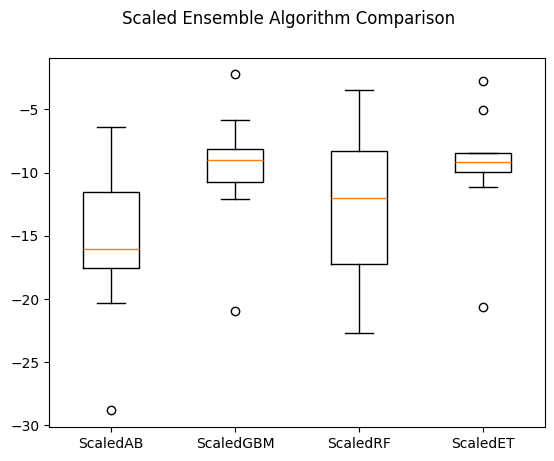

In [40]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Ensemble Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

9. Tune Ensemble Methods

In [42]:
# Tune scaled GBM
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
param_grid = dict(n_estimators=numpy.array([50,100,150,200,250,300,350,400]))
model = GradientBoostingRegressor(random_state=seed)
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledX, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: -9.145857 using {'n_estimators': np.int64(400)}
-10.683863 (5.018729) with: {'n_estimators': np.int64(50)}
-9.843885 (4.662547) with: {'n_estimators': np.int64(100)}
-9.486737 (4.366301) with: {'n_estimators': np.int64(150)}
-9.330334 (4.282711) with: {'n_estimators': np.int64(200)}
-9.227549 (4.132152) with: {'n_estimators': np.int64(250)}
-9.146024 (4.058903) with: {'n_estimators': np.int64(300)}
-9.154305 (4.030297) with: {'n_estimators': np.int64(350)}
-9.145857 (3.996839) with: {'n_estimators': np.int64(400)}


10. Finalize Model

In [44]:
# transform the validation dataset
rescaledValidationX = scaler.transform(X_validation)
predictions = model.predict(rescaledValidationX)
print(mean_squared_error(Y_validation, predictions))

11.902132586880027
